In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
from typing import Any, Sequence

In [2]:
def _mat_get(obj: Any, field: str) -> Any:
    """
    Get a field from a MATLAB struct loaded by scipy.io.loadmat.
    """
    if isinstance(obj, dict):
        if field not in obj:
            raise KeyError(f"Missing field {field!r}.")
        return obj[field]

    if hasattr(obj, field):
        return getattr(obj, field)

    if isinstance(obj, np.void) and obj.dtype.names is not None:
        if field not in obj.dtype.names:
            raise KeyError(f"Missing field {field!r}.")
        return obj[field]

    raise KeyError(f"Missing field {field!r}.")


def _flatten_numeric(value: Any) -> np.ndarray:
    """
    Flatten MATLAB numeric-like values into a 1D float array.
    """
    output = []

    def collect(x):
        if x is None:
            return

        if isinstance(x, np.ndarray):
            if x.dtype == object:
                for item in x.ravel():
                    collect(item)
            else:
                try:
                    arr = x.astype(float).ravel()
                    output.extend(arr[np.isfinite(arr)].tolist())
                except (TypeError, ValueError):
                    return
            return

        if isinstance(x, (list, tuple)):
            for item in x:
                collect(item)
            return

        try:
            number = float(x)
        except (TypeError, ValueError):
            return

        if np.isfinite(number):
            output.append(number)

    collect(value)
    return np.asarray(output, dtype=float)


def _to_int_array(value: Any, *, expected_size: int = 5) -> np.ndarray:
    """
    Convert MATLAB numeric array to 1D integer array.
    """
    arr = _flatten_numeric(value).astype(int)

    if arr.size != expected_size:
        raise ValueError(
            f"Expected {expected_size} values, got {arr.size}: {arr}"
        )

    return arr


def _to_scalar_float(value: Any) -> float:
    """
    Convert MATLAB scalar-like numeric value to float.
    """
    arr = _flatten_numeric(value)

    if arr.size == 0:
        return 0.0

    if arr.size != 1:
        raise ValueError(f"Expected scalar, got {arr}.")

    return float(arr[0])


def load_laps_from_mat(file_path: str | Path) -> list[Any]:
    """
    Load lap array from a MATLAB behavior file.

    The 'class' field is ignored.
    """
    file_path = Path(file_path).expanduser().resolve()

    mat = sio.loadmat(
        file_path,
        squeeze_me=True,
        struct_as_record=False,
    )

    if "lap" not in mat:
        raise KeyError(f"No 'lap' field found in {file_path}.")

    laps = np.asarray(mat["lap"], dtype=object).ravel().tolist()

    if len(laps) == 0:
        raise ValueError(f"No trials found in {file_path}.")

    return laps

In [3]:
def _rule_from_trial_style(trial_style: Sequence[int]) -> str:
    """
    Infer task rule from the first digit of trial_style.

    First digit:
        1 = pattern
        2 = position
    """
    style = np.asarray(trial_style, dtype=int).ravel()

    if style.size != 5:
        raise ValueError(f"trial_style must have 5 values, got {style}.")

    rule_digits = style // 10
    unique_digits = np.unique(rule_digits)

    if unique_digits.size != 1:
        raise ValueError(
            "Inconsistent rule digits within one trial_style: "
            f"trial_style={style}, rule_digits={rule_digits}"
        )

    rule_digit = int(unique_digits[0])

    if rule_digit == 1:
        return "pattern"

    if rule_digit == 2:
        return "position"

    raise ValueError(
        f"Invalid rule digit {rule_digit}. Expected 1 or 2. "
        f"trial_style={style}"
    )


def _decode_trial_style(trial_style: Sequence[int]) -> tuple[str, ...]:
    """
    Decode trial_style into five position-wise cue identities.

    Second digit:
        0 = blank
        1 = A
        2 = B
        3 = C
    """
    code_to_cue = {
        0: "blank",
        1: "A",
        2: "B",
        3: "C",
    }

    cues = []

    for raw_code in np.asarray(trial_style, dtype=int).ravel():
        cue_code = int(raw_code) % 10

        if cue_code not in code_to_cue:
            raise ValueError(
                f"Invalid cue code {cue_code} in trial_style={trial_style}."
            )

        cues.append(code_to_cue[cue_code])

    if cues.count("A") != 1:
        raise ValueError(f"Expected one A cue, got {cues}.")

    if cues.count("B") != 1:
        raise ValueError(f"Expected one B cue, got {cues}.")

    if cues.count("C") != 1:
        raise ValueError(f"Expected one C cue, got {cues}.")

    if cues.count("blank") != 2:
        raise ValueError(f"Expected two blank cues, got {cues}.")

    return tuple(cues)


def _trial_code_from_cues(cues: Sequence[str]) -> str:
    """
    Convert five-position cue sequence into CAB / ACB / ABC style code.
    """
    return "".join(cue for cue in cues if cue != "blank")


def _actions_from_lap(lap: Any, cues: Sequence[str]) -> np.ndarray:
    """
    Convert cue-specific lick numbers into five position-wise actions.

    A lick number > 0 is treated as action = 1.
    """
    lick_by_cue = {
        "A": int(_to_scalar_float(_mat_get(lap, "A_lick_number")) > 0),
        "B": int(_to_scalar_float(_mat_get(lap, "B_lick_number")) > 0),
        "C": int(_to_scalar_float(_mat_get(lap, "C_lick_number")) > 0),
        "blank_one": int(
            _to_scalar_float(_mat_get(lap, "blank_one_lick_number")) > 0
        ),
        "blank_two": int(
            _to_scalar_float(_mat_get(lap, "blank_two_lick_number")) > 0
        ),
    }

    actions = np.zeros(5, dtype=int)
    blank_counter = 0

    for step_index, cue in enumerate(cues):
        if cue in {"A", "B", "C"}:
            actions[step_index] = lick_by_cue[cue]

        elif cue == "blank":
            blank_counter += 1

            if blank_counter == 1:
                actions[step_index] = lick_by_cue["blank_one"]
            elif blank_counter == 2:
                actions[step_index] = lick_by_cue["blank_two"]
            else:
                raise ValueError("More than two blank positions were found.")

        else:
            raise ValueError(f"Unknown cue identity: {cue!r}.")

    return actions

In [4]:
def build_mat_lick_summary(file_path: str | Path) -> tuple[pd.DataFrame, list[int]]:
    """
    Build trial-level lick summary from one MATLAB behavior file.

    This function does not read the MATLAB 'class' field.
    The rule is inferred from the first digit of trial_style.

    Returns
    -------
    trial_summary:
        One row per trial.

    border_index:
        Trial indices where rule switches occur.
    """
    laps = load_laps_from_mat(file_path)

    rows = []

    for trial_id, lap in enumerate(laps):
        trial_style = _to_int_array(
            _mat_get(lap, "trial_style"),
            expected_size=5,
        )

        task_rule = _rule_from_trial_style(trial_style)
        cues = _decode_trial_style(trial_style)
        trial_code = _trial_code_from_cues(cues)
        trial_type = f"{task_rule}_{trial_code}"

        actions = _actions_from_lap(lap, cues)
        licked_positions = np.where(actions > 0)[0].tolist()

        pattern_target_index = int(cues.index("C"))
        position_target_index = 2

        is_diagnostic_trial = bool(
            pattern_target_index != position_target_index
        )

        pattern_target_lick = bool(
            actions[pattern_target_index] > 0
        )

        position_target_lick = bool(
            actions[position_target_index] > 0
        )

        candidate_targets = {
            pattern_target_index,
            position_target_index,
        }

        none_rule_lick = any(
            position not in candidate_targets
            for position in licked_positions
        )

        duplicate_rule_lick = bool(
            is_diagnostic_trial
            and pattern_target_lick
            and position_target_lick
        )

        if task_rule == "pattern":
            true_target_index = pattern_target_index
            false_rule_target_index = position_target_index
        else:
            true_target_index = position_target_index
            false_rule_target_index = pattern_target_index

        true_rule_lick = bool(
            actions[true_target_index] > 0
        )

        false_rule_lick = bool(
            is_diagnostic_trial
            and actions[false_rule_target_index] > 0
        )

        miss_true_target = bool(
            actions[true_target_index] == 0
        )

        # For non-diagnostic trials, the pattern and position targets overlap.
        # To avoid classifying the same lick as a duplicate lick, the shared
        # target lick is plotted according to the actual task rule.
        if is_diagnostic_trial:
            plot_pattern_rule_lick = pattern_target_lick
            plot_position_rule_lick = position_target_lick
        else:
            plot_pattern_rule_lick = bool(
                task_rule == "pattern"
                and pattern_target_lick
            )
            plot_position_rule_lick = bool(
                task_rule == "position"
                and position_target_lick
            )

        if duplicate_rule_lick:
            lick_category = "duplicate_rule_lick"
        elif false_rule_lick:
            lick_category = "wrong_rule_lick"
        elif none_rule_lick:
            lick_category = "none_rule_lick"
        elif miss_true_target:
            lick_category = "miss"
        elif true_rule_lick:
            lick_category = "correct_target_only"
        else:
            lick_category = "no_lick"

        rows.append(
            {
                "trial_id": trial_id,
                "trial_style": trial_style,
                "trial_type": trial_type,
                "task_rule": task_rule,
                "trial_code": trial_code,
                "cues": cues,
                "actions": actions,
                "licked_positions": licked_positions,

                "pattern_target_index": pattern_target_index,
                "position_target_index": position_target_index,
                "true_target_index": true_target_index,
                "false_rule_target_index": false_rule_target_index,

                "is_diagnostic_trial": is_diagnostic_trial,
                "pattern_target_lick": pattern_target_lick,
                "position_target_lick": position_target_lick,
                "true_rule_lick": true_rule_lick,
                "false_rule_lick": false_rule_lick,
                "none_rule_lick": none_rule_lick,
                "duplicate_rule_lick": duplicate_rule_lick,
                "miss_true_target": miss_true_target,

                "plot_pattern_rule_lick": plot_pattern_rule_lick,
                "plot_position_rule_lick": plot_position_rule_lick,

                "lick_category": lick_category,
            }
        )

    trial_summary = pd.DataFrame(rows)

    border_index = []

    for idx in range(1, len(trial_summary)):
        previous_rule = trial_summary.loc[idx - 1, "task_rule"]
        current_rule = trial_summary.loc[idx, "task_rule"]

        if current_rule != previous_rule:
            border_index.append(idx)

    return trial_summary, border_index

In [5]:
def plot_mat_lick_behavior(
    file_path: str | Path,
    *,
    figsize: tuple[float, float] = (10, 3),
    show_summary: bool = True,
    ax=None,
):
    """
    Plot behavior lick types from one MATLAB file.

    Y-axis categories:
        position rule
        pattern rule
        none rule
        duplicate rule

    Marker style:
        filled circle = diagnostic trial
        x marker = non-diagnostic trial

    Returns
    -------
    fig, ax, trial_summary, summary_tables
    """
    trial_summary, border_index = build_mat_lick_summary(file_path)

    pos_rule_lick_idx = trial_summary.index[
        trial_summary["plot_position_rule_lick"]
    ].to_numpy()

    pattern_rule_lick_idx = trial_summary.index[
        trial_summary["plot_pattern_rule_lick"]
    ].to_numpy()

    none_rule_lick_idx = trial_summary.index[
        trial_summary["none_rule_lick"]
    ].to_numpy()

    duplicate_rule_lick_idx = trial_summary.index[
        trial_summary["duplicate_rule_lick"]
    ].to_numpy()

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    def scatter_split_by_diagnostic(indices, y_value, color):
        if len(indices) == 0:
            return

        diagnostic_mask = (
            trial_summary.loc[indices, "is_diagnostic_trial"]
            .to_numpy(dtype=bool)
        )

        diagnostic_indices = indices[diagnostic_mask]
        nondiagnostic_indices = indices[~diagnostic_mask]

        if len(diagnostic_indices) > 0:
            ax.scatter(
                diagnostic_indices,
                np.full_like(diagnostic_indices, y_value, dtype=float),
                c=color,
                s=20,
                marker="o",
            )

        if len(nondiagnostic_indices) > 0:
            ax.scatter(
                nondiagnostic_indices,
                np.full_like(nondiagnostic_indices, y_value, dtype=float),
                c=color,
                s=35,
                marker="x",
                linewidths=1.2,
            )

    scatter_split_by_diagnostic(
        pattern_rule_lick_idx,
        2,
        "tab:blue",
    )

    scatter_split_by_diagnostic(
        pos_rule_lick_idx,
        1,
        "tab:orange",
    )

    scatter_split_by_diagnostic(
        none_rule_lick_idx,
        3,
        "tab:red",
    )

    scatter_split_by_diagnostic(
        duplicate_rule_lick_idx,
        4,
        "tab:green",
    )

    for border in border_index:
        ax.axvline(
            border,
            color="k",
            linestyle="--",
            linewidth=1.5,
        )

    ax.set_ylim(0.5, 4.5)
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels(
        [
            "position rule",
            "pattern rule",
            "none rule",
            "duplicate rule",
        ]
    )

    ax.set_xlabel("trial index")
    ax.set_ylabel("lick type")
    ax.grid(axis="x", linestyle=":", alpha=0.3)

    color_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="tab:blue",
            markeredgecolor="tab:blue",
            markersize=6,
            label="pattern rule",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="tab:orange",
            markeredgecolor="tab:orange",
            markersize=6,
            label="position rule",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="tab:red",
            markeredgecolor="tab:red",
            markersize=6,
            label="none rule lick",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="tab:green",
            markeredgecolor="tab:green",
            markersize=6,
            label="duplicate rule lick",
        ),
    ]

    marker_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            color="k",
            markersize=6,
            label="diagnostic trial",
        ),
        Line2D(
            [0],
            [0],
            marker="x",
            linestyle="none",
            color="k",
            markersize=7,
            label="non-diagnostic trial",
        ),
    ]

    legend_1 = ax.legend(
        handles=color_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        borderaxespad=0.0,
        title="lick type",
    )

    ax.add_artist(legend_1)

    ax.legend(
        handles=marker_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 0.43),
        borderaxespad=0.0,
        title="trial type",
    )

    plt.tight_layout()

    summary_tables = {
        "lick_category_by_diagnostic": pd.crosstab(
            trial_summary["is_diagnostic_trial"],
            trial_summary["lick_category"],
        ),
        "duplicate_by_diagnostic": pd.crosstab(
            trial_summary["is_diagnostic_trial"],
            trial_summary["duplicate_rule_lick"],
        ),
        "none_rule_by_diagnostic": pd.crosstab(
            trial_summary["is_diagnostic_trial"],
            trial_summary["none_rule_lick"],
        ),
        "false_rule_by_diagnostic": pd.crosstab(
            trial_summary["is_diagnostic_trial"],
            trial_summary["false_rule_lick"],
        ),
    }

    if show_summary:
        print(f"File: {Path(file_path).name}")
        print(f"n_trials = {len(trial_summary)}")
        print(f"switch borders = {border_index}")
        print()
        print("Lick category by diagnostic trial:")
        print(summary_tables["lick_category_by_diagnostic"])
        print()
        print("Duplicate rule lick by diagnostic trial:")
        print(summary_tables["duplicate_by_diagnostic"])
        print()
        print("None rule lick by diagnostic trial:")
        print(summary_tables["none_rule_by_diagnostic"])

    return fig, ax, trial_summary, summary_tables

File: RE11_L-PFC-HPC-2_POSI-PATT-POSI_LickTask_rev_2026-03-21_lap.mat
n_trials = 192
switch borders = [33, 113]

Lick category by diagnostic trial:
lick_category        correct_target_only  duplicate_rule_lick  miss  \
is_diagnostic_trial                                                   
False                                 63                    0     1   
True                                  63                   39    10   

lick_category        none_rule_lick  wrong_rule_lick  
is_diagnostic_trial                                   
False                             3                0  
True                              2               11  

Duplicate rule lick by diagnostic trial:
duplicate_rule_lick  False  True 
is_diagnostic_trial              
False                   67      0
True                    86     39

None rule lick by diagnostic trial:
none_rule_lick       False  True 
is_diagnostic_trial              
False                   64      3
True                   120    

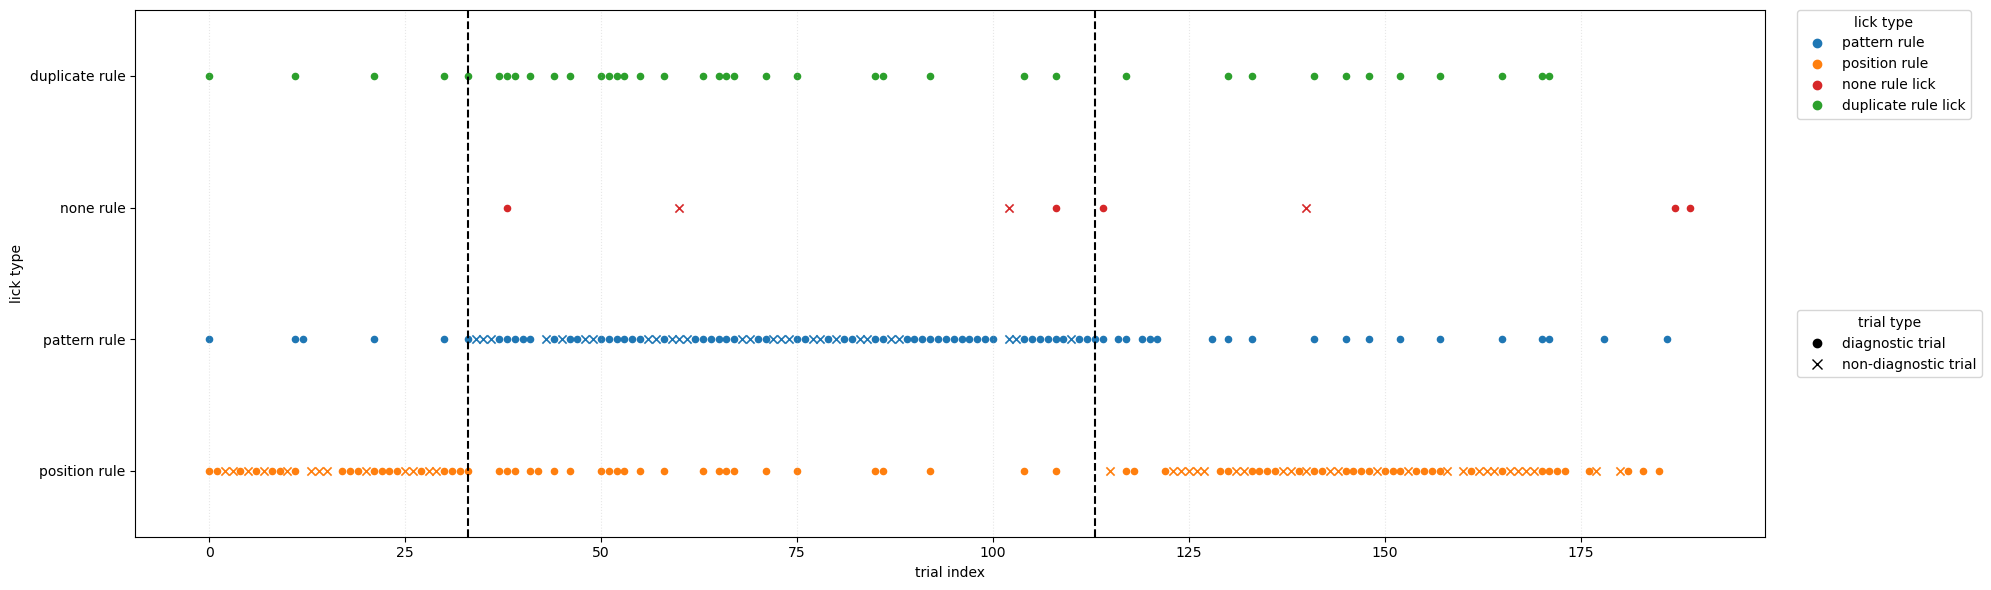

In [21]:
file_path = "../../data/PFC_NP/flexible_shift/Behavior only/RE11_L-PFC-HPC-2_POSI-PATT-POSI_LickTask_rev_2026-03-21_lap.mat"

fig, ax, trial_summary, summary_tables = plot_mat_lick_behavior(
    file_path,
    show_summary=True,
    figsize=(20, 6)
)

plt.show()